In [4]:
using Pkg
Pkg.activate(".")
Pkg.add(["Polyhedra", "CDDLib", "Plots", "HiGHS", "NEOSServer", "JuMP"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/felipe/trabuco/Polyhedron`
   Resolving package versions...
  No Changes to `~/felipe/trabuco/Polyhedron/Project.toml`
  No Changes to `~/felipe/trabuco/Polyhedron/Manifest.toml`


In [5]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.8

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

declarar as variáveis para o sistema de tanques com atraso d = 2, delta = 0.8

In [ ]:
result_1 = Poly.finding_L_pinvariant_segref_delay_sim(A_exp, B_exp, E_exp, S, R, d, lambda=0.999, lf=24, time=120)

Job 18739769 dispatched
password: wmYdUTJR
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'

Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.



In [113]:
using LinearAlgebra

F = result_1["F"]
F = vcat(F, -F)

48×4 Matrix{Float64}:
 -0.000270066   0.00128233    6.82492e-5   -0.00401255
  0.00195255    0.00261363   -0.000116476   3.5995e-5
  0.00253259    0.00338146   -0.000151214   3.11027e-5
 -0.00156396   -0.0020942     9.28258e-5   -5.24805e-5
  0.004838      0.00641287   -0.000287      0.000109898
  0.014745      0.044121     -0.00144333    7.93906e-5
  0.00182554    0.00244576   -0.000108901   3.49537e-5
 -0.000194381   0.000689181   3.91603e-5   -4.85852e-5
 -0.343071     -0.354656      0.016728      7.86171e-7
  0.000750672   0.000775955   0.00330335    6.5929e-8
  0.000616494   0.000833673  -3.71718e-5    3.16018e-6
  0.00170486    0.00228525   -0.000101738   3.35716e-5
 -0.000490877   0.00349052   -0.000135472  -0.0126655
  ⋮                                        
  0.000490877  -0.00349052    0.000135472   0.0126655
 -1.92913e-5   -2.60028e-5    1.15261e-6   -6.32455e-7
  0.0356648     0.214433     -0.00693639    5.51924e-8
 -4.5069e-5    -6.43757e-5    3.10598e-6    1.50332e-5
 -

In [20]:
G = result_1["G"]

1×4 Matrix{Float64}:
 -1.00055  -1.01744  0.0462952  0.106328

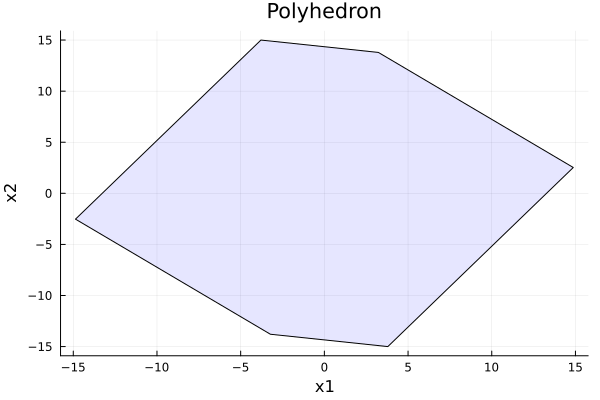

In [114]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

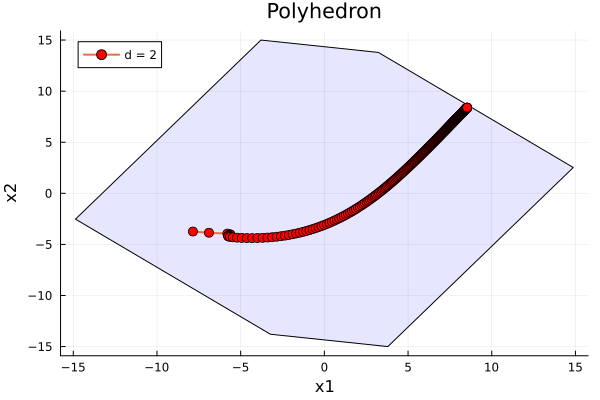

In [117]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 300
r = ones(passos)*8.7 # escolher a referência a se seguir 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj]
x2 = [p[2] for p in traj]
v = [p[3] for p in traj]
w = [p[4] for p in traj]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

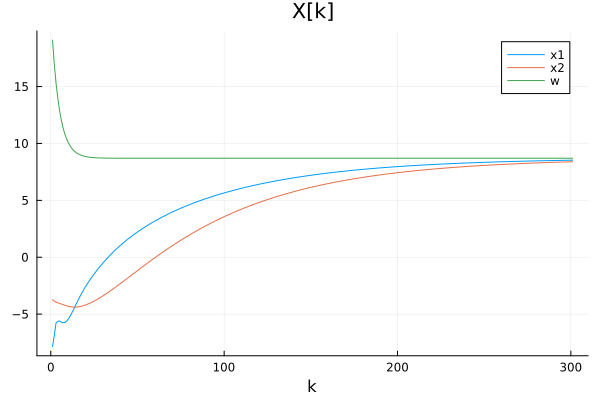

In [118]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

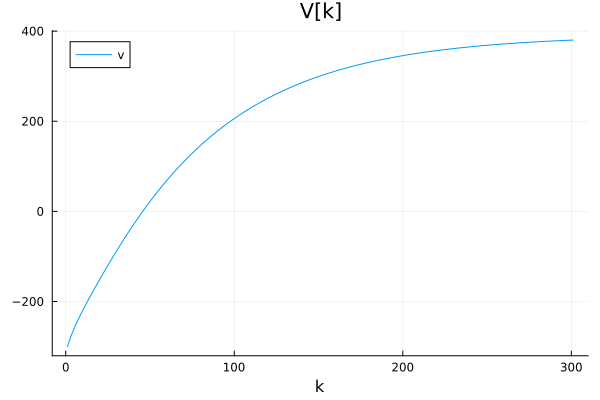

In [119]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

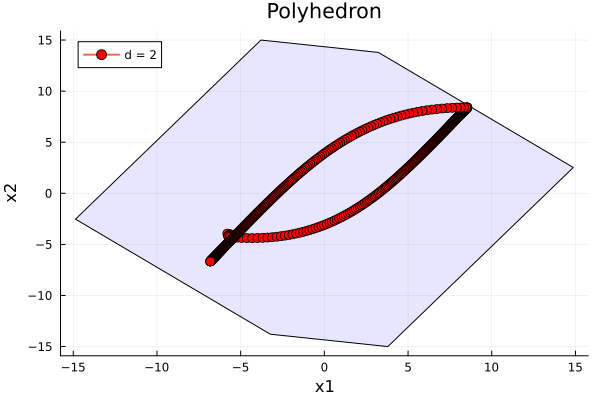

In [120]:
r = ones(passos) * -7

traj2 =Poly.trajectory_segref_delay(traj, A_exp, BG, E_exp, r, passos, d; reverse=false)
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj2]
x2 = [p[2] for p in traj2]
v = [p[3] for p in traj2]
w = [p[4] for p in traj2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

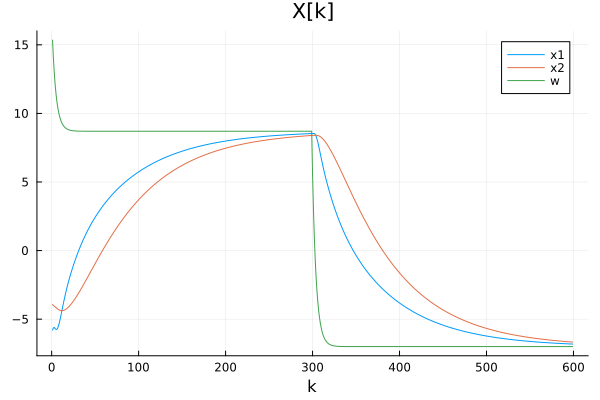

In [121]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

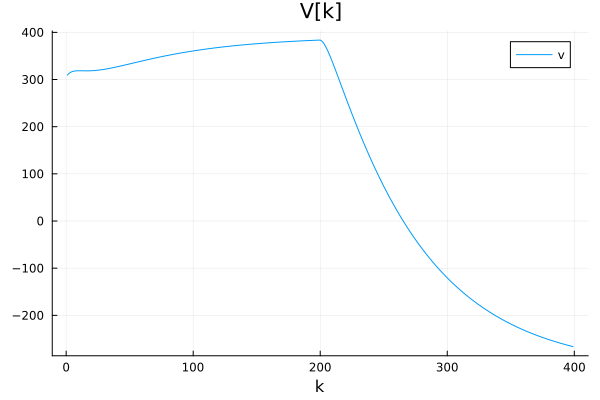

In [56]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

delta = 0.75

In [80]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.75

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

result_2 = Poly.finding_L_pinvariant_segref_delay_sim(A_exp, B_exp, E_exp, S, R, d, lambda=0.999, lf=24, time=5)

Job 18737946 dispatched
password: ZhCXKNvy

---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 32 entries:
  "P_diff" => [0.000121593 -0.000121593; 0.000114808 -0.000114808; … ; 0.12407 …
  "Zm"     => [149.633 149.634 … 149.632 149.633; 149.635 149.635 … 149.634 149…
  "P_sum"  => [0.0101339 0.0101339; 0.0101437 0.0101437; … ; 0.124074 0.124074;…
  "Zp"     => [149.632 149.631 … 149.633 149.632; 149.635 149.636 … 149.636 149…
  "M_diff" => [-8.73591e-9 -2.18269e-9 … -2.82215e-6 -5.62472e-12; 3.33659e-9 1…
  "Hp"     => [0.00507124 0.005067 … 0.00543108 0.00506638; 0.00507143 0.005071…
  "Tp"     => [0.000440184 0.000440908 … 0.000472811 0.000441313; 0.000341034 0…
  "Z_sum"  => [299.265 299.265 … 299.265 299.265; 299.27 299.27 … 299.27 299.27…
  "H_diff" => [9.6964e-6 1.22217e-6 … 0.000687851 -7.34334e-10; 1.62582e-7 -4.2…
  "Mm"     => [0.0025332 0.00253319 … 0.0025346 0.00253319; 0.00253567 0.002535…
  "H_sum"  => [0.0101328 0.0101328 … 0.0101743 0.0101328; 0.0101427 0.0101427 ……
  "Z_diff" => [-0.000784104 -0.00202787 … 0.00162124 -0.001621

In [81]:
F2 = result_2["F"]
F2 = vcat(F2, -F2)

48×4 Matrix{Float64}:
 -0.000104547  -0.000270383  -4.89114e-7   6.48496e-5
  3.45872e-5    0.00013214   -6.48008e-6   6.12307e-5
  6.081e-5      0.000129957   3.97612e-6  -9.13628e-5
  4.33352e-5    9.80459e-5    2.05022e-6  -5.27354e-5
  1.13437e-5    2.21116e-5    8.34547e-7  -2.23408e-5
  8.08169e-5    0.000242933  -6.5609e-6    2.5461e-6
 -2.43004e-5   -6.81178e-5    9.50592e-7   6.36774e-6
  1.62948e-6    4.23717e-6   -1.58533e-8  -1.1339e-6
  3.08501e-6    0.000102552  -1.57368e-5   0.000146177
 -6.54269e-5   -0.000189912   4.61562e-6   1.50139e-5
  9.00868e-5    0.000251817  -3.85126e-6  -2.9715e-5
  0.342438      0.412893     -0.0182642   -6.80717e-5
  2.19526e-6    7.3454e-6     1.64817e-7   8.07254e-6
  ⋮                                       
 -2.19526e-6   -7.3454e-6    -1.64817e-7  -8.07254e-6
  5.79909e-5    0.000162013  -1.95441e-6  -5.14058e-6
 -1.45044e-6   -1.58072e-6   -3.63263e-7   4.77738e-6
 -5.4208e-5    -0.000164163   4.7192e-6   -2.15103e-6
 -1.55197e-5   -5.4

In [83]:
G2 = result_2["G"]

1×4 Matrix{Float64}:
 -0.942618  -1.03256  0.0486537  0.131864

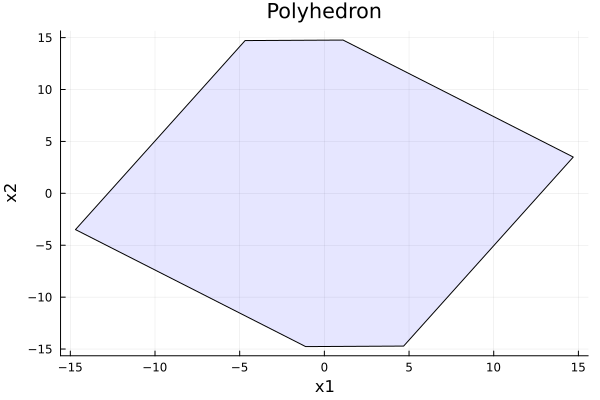

In [82]:
T2 = Poly.poly_projection(F2[:,3:4])
Poly.plot_poly(T2*F2[:,1:2], T2*ones(size(F2, 1)))

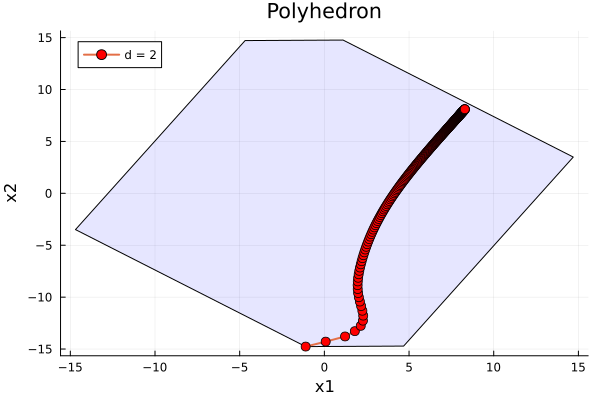

In [86]:
using Plots

w2 = ones(size(F2, 1))
nx = size(A_exp, 1)

passos = 250
r = ones(passos)*8.5 # escolher a referência a se seguir 

BG2 = B_exp * G2

init_cond_F2, init_cond_w2 = Poly.admissable_initCond(A_exp, BG2, F2, d, w2; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F2, init_cond_w2, 2, nx)
traj3 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG2, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T2*F2[:,1:2], T2*ones(size(F2, 1)))

x1 = [p[1] for p in traj3]
x2 = [p[2] for p in traj3]
v = [p[3] for p in traj3]
w = [p[4] for p in traj3]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

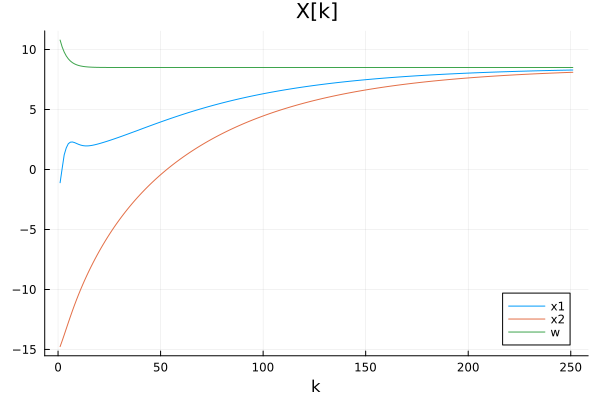

In [87]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

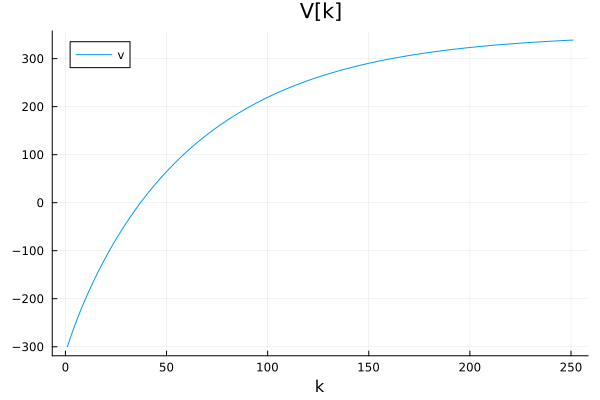

In [88]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

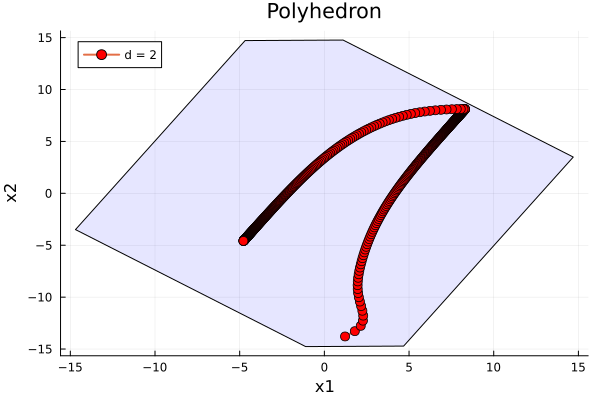

In [89]:
r = ones(passos) * -5

traj4 =Poly.trajectory_segref_delay(traj3, A_exp, BG2, E_exp, r, passos, d; reverse=false)
Poly.plot_poly(T2*F2[:,1:2], T2*ones(size(F2, 1)))

x1 = [p[1] for p in traj4]
x2 = [p[2] for p in traj4]
v = [p[3] for p in traj4]
w = [p[4] for p in traj4]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

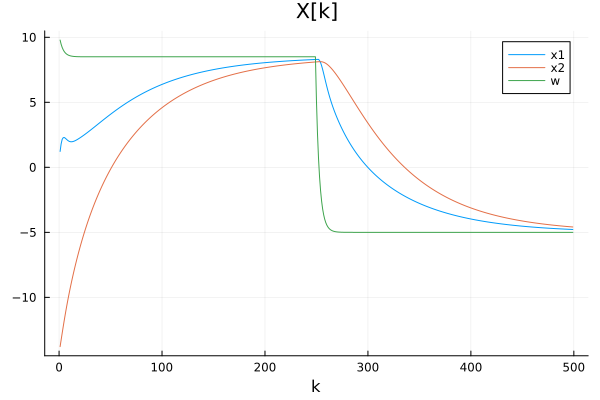

In [90]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

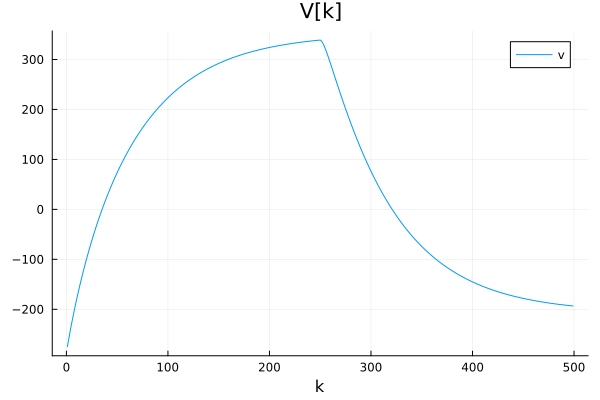

In [91]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

delta = 0.65

In [10]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.725

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

result_3 = Poly.finding_L_pinvariant_segref_delay_sim(A_exp, B_exp, E_exp, S, R, d, lambda=0.999, lf=24, time=25)

Job 18739482 dispatched
password: AecGzBMV

---------- Begin Solver Output -----------
Condor submit: 'neos.submit'

Condor submit: 'watchdog.submit'

Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 32 entries:
  "P_diff" => [-0.0008592 0.0008592; 0.0189894 -0.0189894; … ; -0.00332625 0.00…
  "Zm"     => [0.323243 0.305825 … 0.319758 0.309343; 0.828635 0.966071 … 0.000…
  "P_sum"  => [0.00532501 0.00532501; 0.0192471 0.0192471; … ; 0.00332694 0.003…
  "Zp"     => [0.314914 0.322858 … 0.309343 0.319758; 0.00116868 0.00104245 … 0…
  "M_diff" => [-2.89235e-6 2.37124e-5 … 1.18844e-5 4.21664e-8; 8.87828e-5 0.000…
  "Hp"     => [0.00812874 0.00460817 … 0.00119157 0.00246559; 0.00042905 0.8251…
  "Tp"     => [0.00158008 0.000485983 … 0.000331242 0.000655652; 0.00443635 0.0…
  "Z_sum"  => [0.638157 0.628683 … 0.6291 0.629101; 0.829804 0.967114 … 0.23204…
  "H_diff" => [0.00652143 0.00269098 … -0.212667 -0.000321538; 0.000245586 0.82…
  "Mm"     => [0.00130795 0.00129555 … 0.00130027 0.00130636; 9.60479e-5 7.5703…
  "H_sum"  => [0.00973605 0.00652537 … 0.21505 0.00525272; 0.000612514 0.825314…
  "Z_diff" => [-0.00832906 0.0170325 … -0.0104147 0.0104145; -

In [11]:
F3 = result_3["F"]
F3 = vcat(F3, -F3)

48×4 Matrix{Float64}:
 -0.00111067    0.00227091    0.00152875   -0.000416575
 -0.110329     -0.128671      0.00528844    0.00920718
  0.131117      0.0558424    -0.00346319   -9.61984e-6
 -0.000199838   0.00729563    6.68008e-5   -0.000758418
  0.0489574     0.179454     -0.00565409   -0.0102205
 -0.000561663  -0.0542057     0.00152279    0.0451626
  0.00355318    0.00297129   -9.86523e-5   -3.58019e-6
  0.000501662   0.0150517    -0.000118808   0.000104871
 -0.000347086   0.00141761    0.00295431   -0.00192181
 -0.000449426   0.000912586   0.00257618   -0.00149981
  ⋮                                        
 -7.23747e-7    3.59314e-5    0.00333945   -1.02298e-5
  0.0028838    -0.00340795   -0.00116909    0.000413336
  0.0401027     0.0212844    -0.00115931    3.78133e-6
  0.00108104   -0.00511421   -8.34147e-5    0.000750047
  0.00151462   -0.000354197  -0.00195443    0.000123374
 -0.00222525    0.168894     -0.00456922   -5.17901e-5
  0.00081256   -0.00489927   -0.00190452    0.0009

In [14]:
G3 = result_3["G"]

1×4 Matrix{Float64}:
 -0.736984  -0.878329  0.037088  0.0688598

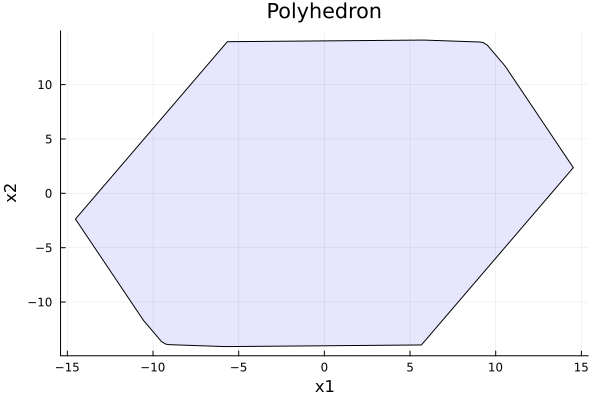

In [12]:
T3 = Poly.poly_projection(F3[:,3:4])
Poly.plot_poly(T3*F3[:,1:2], T3*ones(size(F3, 1)))

In [16]:
using Plots

w3 = ones(size(F3, 1))
nx = size(A_exp, 1)

passos = 200
r = ones(passos)*3 # escolher a referência a se seguir 

BG3 = B_exp * G3

init_cond_F3, init_cond_w3 = Poly.admissable_initCond(A_exp, BG3, F3, d, w3; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F3, init_cond_w3, 2, nx)
traj5 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG3, E_exp, r, passos, d; reverse=true)

Poly.plot_poly(T3*F3[:,1:2], T3*ones(size(F3, 1)))

x1 = [p[1] for p in traj5]
x2 = [p[2] for p in traj5]
v = [p[3] for p in traj5]
w = [p[4] for p in traj5]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

BoundsError: BoundsError: attempt to access 0-element Vector{Vector{Float64}} at index [2]

delta = 0.6

In [6]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.6

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

result_4 = Poly.finding_L_pinvariant_segref_delay_sim(A_exp, B_exp, E_exp, S, R, d, lambda=0.999, lf=24, time=30)

Job 18739442 dispatched
password: XCimcjHN

---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 32 entries:
  "P_diff" => [0.00268183 -0.00268183; 0.021398 -0.021398; … ; 0.000631366 -0.0…
  "Zm"     => [8.57944 5.52889 … 0.016276 0.0386246; 1.19868 0.962322 … 1.44227…
  "P_sum"  => [0.00320564 0.00320564; 0.0253358 0.0253358; … ; 0.0101687 0.0101…
  "Zp"     => [0.0135353 0.0135601 … 0.0386246 0.016276; 1.99424 2.58026 … 1.62…
  "M_diff" => [-0.00249314 2.98929e-5 … 1.67998e-7 1.11195e-6; 0.000224552 -1.9…
  "Hp"     => [0.78132 0.000553161 … 0.000483844 0.000469751; 0.00188059 0.0052…
  "Tp"     => [0.0111557 0.0183994 … 0.0189522 0.019201; 0.0257626 0.0199537 … …
  "Z_sum"  => [8.59297 5.54245 … 0.0549006 0.0549006; 3.19292 3.54258 … 3.06287…
  "H_diff" => [0.781077 0.000122729 … -9.95493e-7 -3.01005e-5; -0.0538681 0.002…
  "Mm"     => [0.00262016 0.000227955 … 0.000242092 0.000241615; 0.00171093 0.0…
  "H_sum"  => [0.781562 0.000983593 … 0.000968683 0.000969602; 0.0576293 0.0080…
  "Z_diff" => [-8.5659 -5.51533 … 0.0223486 -0.0223486; 0.7955

In [7]:
F4 = result_4["F"]
F4 = vcat(F4, -F4)
G4 = result_4["G"]  

1×4 Matrix{Float64}:
 -1.04085  -0.673394  0.00236827  0.00318086

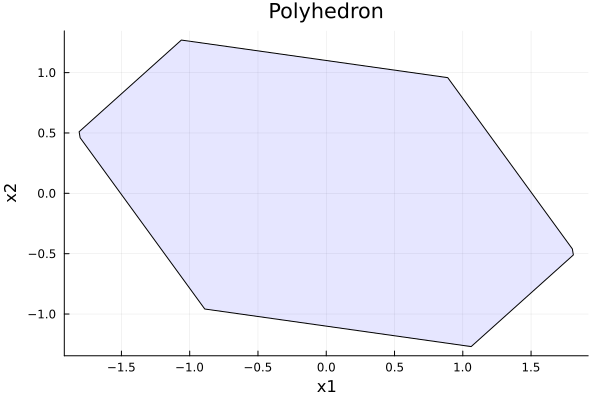

In [8]:
T4 = Poly.poly_projection(F4[:,3:4])
Poly.plot_poly(T4*F4[:,1:2], T4*ones(size(F4, 1)))

In [9]:
using Plots

w4 = ones(size(F4, 1))
nx = size(A_exp, 1)

passos = 200
r = ones(passos)*3 # escolher a referência a se seguir 

BG4 = B_exp * G4

init_cond_F4, init_cond_w4 = Poly.admissable_initCond(A_exp, BG4, F4, d, w4; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F4, init_cond_w4, 2, nx)
traj6 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG4, E_exp, r, passos, d; reverse=true)
Poly.plot_poly(T4*F4[:,1:2], T4*ones(size(F4, 1)))

x1 = [p[1] for p in traj6]
x2 = [p[2] for p in traj6]
v = [p[3] for p in traj6]
w = [p[4] for p in traj6]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

BoundsError: BoundsError: attempt to access 0-element Vector{Vector{Float64}} at index [2]